In [1]:
import pandas as pd
import numpy as np
import mglearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [3]:
rnd = np.random.RandomState(0)
x_org = rnd.normal(size=(1000,3))
w = rnd.normal(size=3)

x = rnd.poisson(10 * np.exp(x_org))
y = np.dot(x_org,w)

print("Number of features appearances:\n{}".format(np.bincount(x[:,0])))

Number of features appearances:
[28 38 68 48 61 59 45 56 37 40 35 34 36 26 23 26 27 21 23 23 18 21 10  9
 17  9  7 14 12  7  3  8  4  5  5  3  4  2  4  1  1  3  2  5  3  8  2  5
  2  1  2  3  3  2  2  3  3  0  1  2  1  0  0  3  1  0  0  0  1  3  0  1
  0  2  0  1  1  0  0  0  0  1  0  0  2  2  0  1  1  0  0  0  0  1  1  0
  0  0  0  0  0  0  1  0  0  0  0  0  1  1  0  0  1  0  0  0  0  0  0  0
  1  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1]


Text(0.5, 0, 'Value')

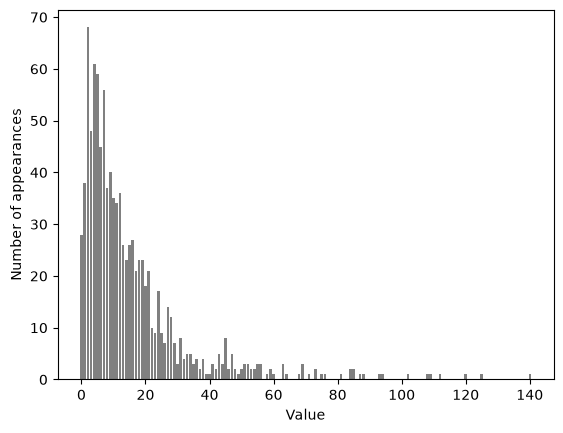

In [4]:
#分布を可視化
bins = np.bincount(x[:,0])
plt.bar(range(len(bins)), bins,color='gray')
plt.ylabel("Number of appearances")
plt.xlabel("Value")

In [5]:
#このようなデータは多くの線形モデルではうまく扱えない
from sklearn.linear_model import Ridge
x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=0)
score = Ridge().fit(x_train,y_train).score(x_test,y_test)
print("Ridge score: {:.2f}".format(score))

Ridge score: 0.62


Text(0, 0.5, 'Number of appearances')

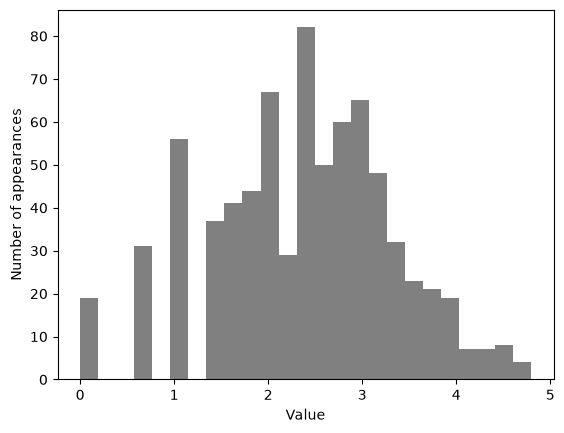

In [6]:
#対数変換する
#logは０を含むと計算できないので、1を足す

x_train_log = np.log(x_train+1)
x_test_log = np.log(x_test+1)

#変換後のデータ分散は非対称性が少なく、非常に大きい外れ値は失くなっている
plt.hist(x_train_log[:,0],bins=25,color='gray')
plt.xlabel("Value")
plt.ylabel("Number of appearances")

In [7]:
score = Ridge().fit(x_train_log,y_train).score(x_test_log,y_test)
print("Ridge score after log transform: {:.2f}".format(score))

Ridge score after log transform: 0.87


今回はすべての特徴量が同じ特性を持っていたが、現実の多くの場合は、特徴量の一部だけを変換することになる